In [18]:
# =========================
# 1. IMPORT LIBRARY
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [19]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/paris_housing_prices_dataset_tgs6.csv')
df.head()

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,Apartment,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,Studio,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,Apartment,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,Apartment,35,1,5,1938,New,4.72,407781.74
4,P10004,7,Studio,73,2,2,1957,New,7.96,624879.12


In [20]:
# =========================
# 3. EKSPLORASI DATA
# =========================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Property_ID            1200 non-null   object 
 1   Arrondissement         1200 non-null   int64  
 2   Property_Type          1200 non-null   object 
 3   Size_sqm               1200 non-null   int64  
 4   Rooms                  1200 non-null   int64  
 5   Floor                  1200 non-null   int64  
 6   Year_Built             1200 non-null   int64  
 7   Condition              1200 non-null   object 
 8   Distance_to_Center_km  1200 non-null   float64
 9   Price_EUR              1200 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 93.9+ KB


In [21]:
df.describe()

,Arrondissement,Size_sqm,Rooms,Floor,Year_Built,Distance_to_Center_km,Price_EUR
count,1200.00000,1200.000000,1200.000000,1200.000000,1200.0000,1200.000000,1.200000e+03
mean,10.81750,108.125833,3.000000,4.390833,1935.6725,7.755375,1.521459e+06
std,5.65811,54.176125,1.414214,2.899728,49.8934,4.179961,8.737896e+05
min,1.00000,15.000000,1.000000,0.000000,1850.0000,0.510000,1.205258e+05
25%,6.00000,62.000000,2.000000,2.000000,1894.0000,4.137500,7.847546e+05
50%,11.00000,108.000000,3.000000,4.000000,1935.0000,7.705000,1.430473e+06
75%,16.00000,157.000000,4.000000,7.000000,1977.0000,11.347500,2.125367e+06
max,20.00000,199.000000,5.000000,9.000000,2023.0000,14.990000,3.950832e+06


In [22]:
df.isnull().sum()

,0
Property_ID,0
Arrondissement,0
Property_Type,0
Size_sqm,0
Rooms,0
Floor,0
Year_Built,0
Condition,0
Distance_to_Center_km,0
Price_EUR,0


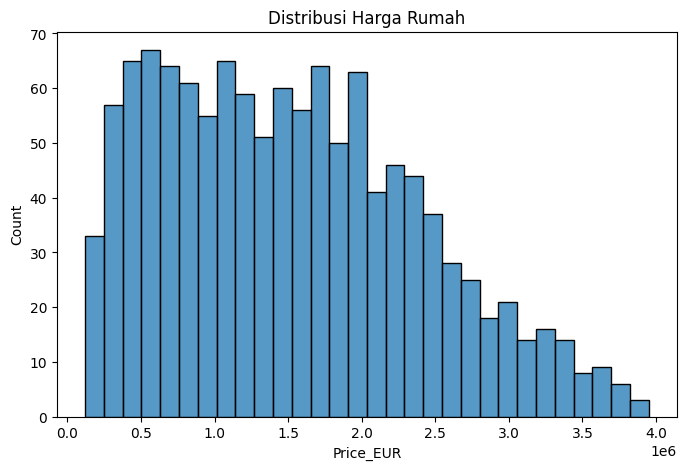

In [23]:
# =========================
# 4. ANALISIS EDA
# =========================

# Histogram harga rumah
plt.figure(figsize=(8,5))
sns.histplot(df['Price_EUR'], bins=30)
plt.title('Distribusi Harga Rumah')
plt.show()

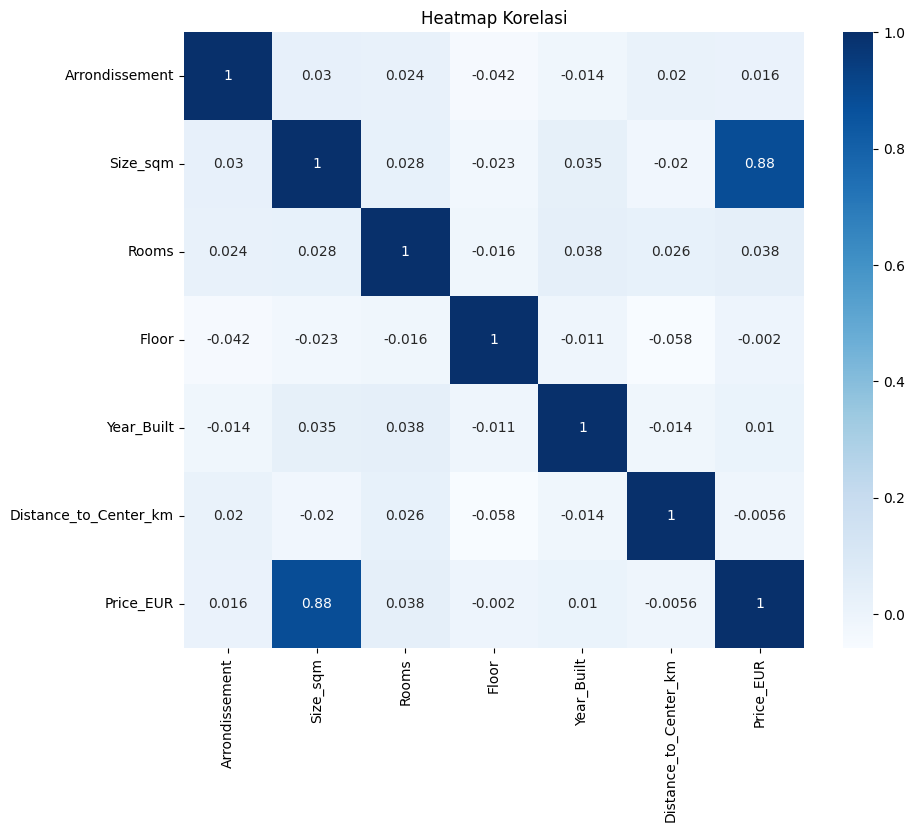

In [24]:
# Heatmap korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('Heatmap Korelasi')
plt.show()

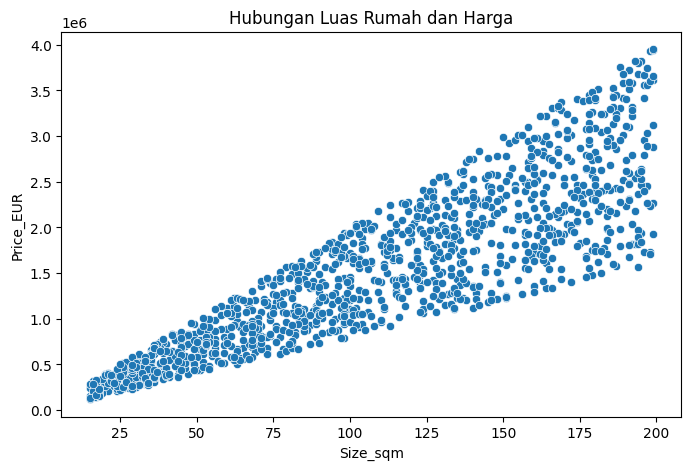

In [25]:
# Scatterplot luas rumah dan harga
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Size_sqm'],
    y=df['Price_EUR']
)
plt.title('Hubungan Luas Rumah dan Harga')
plt.show()

In [26]:
# =========================
# 5. PREPROCESSING DATA
# =========================

# Menghapus kolom ID
df = df.drop('Property_ID', axis=1)

# Encoding data kategorikal
le = LabelEncoder()
df['Property_Type'] = le.fit_transform(df['Property_Type'])
df['Condition'] = le.fit_transform(df['Condition'])
df.head()

,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,4,0,117,4,7,1870,3,2.76,2270802.89
1,8,3,89,3,3,1953,0,10.77,1637076.12
2,4,0,164,5,5,1979,1,3.14,3220782.59
3,2,0,35,1,5,1938,2,4.72,407781.74
4,7,3,73,2,2,1957,2,7.96,624879.12


In [27]:
#6.

# Memisahkan fitur dan target
X = df.drop('Price_EUR', axis=1)

# Menyimpan nama fitur
feature_names = X.columns

# Target
y = df['Price_EUR']

# Encoding data kategorikal
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X.shape)
print("Preprocessing berhasil")

(1200, 8)
Preprocessing berhasil


In [28]:
# =========================
# 7. PEMBANGUNAN MODEL
# =========================

# -------------------------
# Linear Regression
# ------------------------
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)


# -------------------------
# Decision Tree
# -------------------------
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)


# -------------------------
# Random Forest
# -------------------------
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)


In [29]:
# =========================
# 8. EVALUASI MODEL
# =========================

def evaluasi(nama_model, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print("Model :", nama_model)
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R2 Score :", r2)
    print()


# Evaluasi Linear Regression
evaluasi("Linear Regression", y_test, y_pred_lr)

# Evaluasi Decision Tree
evaluasi("Decision Tree", y_test, y_pred_dt)

# Evaluasi Random Forest
evaluasi("Random Forest", y_test, y_pred_rf)


Model : Linear Regression
MAE : 321765.20867726865
MSE : 167898018648.82977
RMSE : 409753.6072432185
R2 Score : 0.7830141901718406

Model : Decision Tree
MAE : 444120.2795416667
MSE : 394809844992.9893
RMSE : 628338.9570868491
R2 Score : 0.4897608999001074

Model : Random Forest
MAE : 332036.4375191667
MSE : 184732724943.71246
RMSE : 429805.4501093634
R2 Score : 0.7612575761986011



In [30]:
# Perbandingan Model

hasil = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

print(hasil)

               Model  R2 Score
0  Linear Regression  0.783014
1      Decision Tree  0.489761
2      Random Forest  0.761258


In [31]:
# =========================
# 9. HYPERPARAMETER TUNING
# =========================

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3
)
grid.fit(X_train, y_train)
grid.best_params_
print(grid.best_params_)

# Model terbaik
best_rf = grid.best_estimator_

# Prediksi
y_pred_best = best_rf.predict(X_test)

# Evaluasi
evaluasi("Random Forest Tuning", y_test, y_pred_best)

{'max_depth': 5, 'n_estimators': 100}
Model : Random Forest Tuning
MAE : 330740.37818653614
MSE : 179207973840.56418
RMSE : 423329.6278794625
R2 Score : 0.7683975806004578



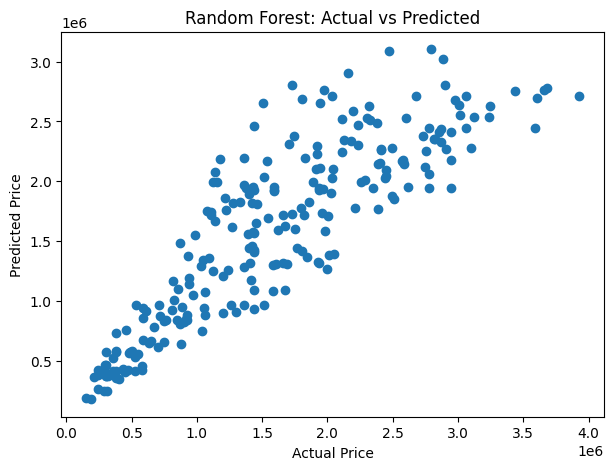

In [32]:
# =========================
# 10. VISUALISASI HASIL
# =========================

# Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show(

)

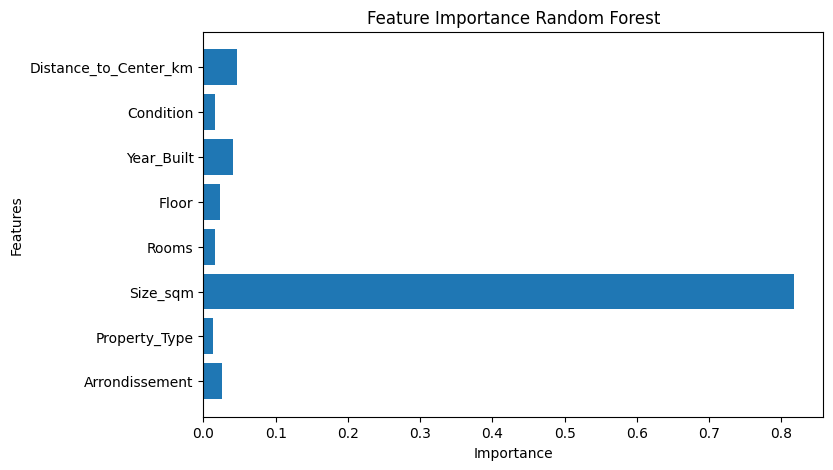

In [33]:
# =========================
# 11. FEATURE IMPORTANCE
# =========================

importance = model_rf.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(feature_names, importance)
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()